In [1]:
import allel
print("allel:",allel.__version__)
import numpy as np
print("numpy:",np.__version__)

import re
import sys

from tabulate import tabulate
import pandas as pd

allel: 1.3.5
numpy: 1.21.6


In [2]:
from plotnine import *

In [3]:
#vcf='phased_shapeit_1_200samples.vcf.gz'
vcffile='resources/Aaeg1200g/aegy.wgs.aaa.aaf.norep5-30x.ac10.thinrand01.phased.chr{}.vcf.gz'
#vcf='resources/Aaeg1200g/aegy.wgs.aaa.aaf.mapQ20.GoodSites.chr3.SNP.refseq.7e6.phased.vcf.gz'
#vcf='resources/Aaeg1200g/shapeit.kdr3.vcf.gz'
metafile='resources/meta_Aaeg1kg_spp.txt'

meta = pd.read_csv(metafile, sep='\t')

meta = np.genfromtxt(metafile,delimiter='\t',names=True,dtype=None,encoding='utf-8')



In [16]:
meta

array([('Debug019_aegypti_El_Dorado_Argentina_U_10', 'ElDorado', 'ADMX', 'South America', 'Americas', 'Argentina'),
       ('Debug019_aegypti_El_Dorado_Argentina_U_11', 'ElDorado', 'ADMX', 'South America', 'Americas', 'Argentina'),
       ('Debug019_aegypti_El_Dorado_Argentina_U_2', 'ElDorado', 'ADMX', 'South America', 'Americas', 'Argentina'),
       ...,
       ('Debug010_aegypti_Tahiti_FrenchPolynesia_18', 'Tahiti', 'AAA', 'Pacific', 'Asia', 'Tahiti'),
       ('Debug010_aegypti_Tahiti_FrenchPolynesia_19', 'Tahiti', 'AAA', 'Pacific', 'Asia', 'Tahiti'),
       ('Debug010_aegypti_Tahiti_FrenchPolynesia_20', 'Tahiti', 'AAA', 'Pacific', 'Asia', 'Tahiti')],
      dtype=[('sample', '<U59'), ('pop', '<U14'), ('spp', '<U4'), ('region', '<U13'), ('contgroup', '<U8'), ('country', '<U15')])

In [14]:
hapsfile = 'resources/aaeg_hap_loci.txt'
haps = pd.read_csv(hapsfile, sep='\t')
haps['pos'] = round(np.mean(haps[['start','end']],1))
haps['chr'] = haps['chrom']
haps = haps[haps['locusname'].isin(['kdr3','ace','rdl2'])]
haps

,chrom,start,end,locusname,geneid,regionstring,pos,chr
0,2,41628484,41861946,rdl2,AAEL008354,NC_035108.1:41628484-41861946,41745215.0,2
2,3,315926360,316405639,kdr3,AAEL023266,NC_035109.1:315926360-316405639,316166000.0,3
4,1,142163173,142283642,ace,AAEL021432,NC_035107.1:142163173-142283642,142223408.0,1


In [4]:
poplevel = 'country'
pop1='USA'

pops, popn = np.unique(meta['pop'][meta[poplevel]==pop1], return_counts=True)
pd.DataFrame({"pop":pops,
              "popn":popn})

,pop,popn
0,Clovis,16
1,Coachella,19
2,LasCruces,18
3,LosAngeles,20
4,MaricopaCounty,23
5,Miami,15
6,NewOrleans,15
7,Roswell,19


In [5]:
h12tab = pd.DataFrame(columns = ["cnt","pop","chr","pos","h1","h12","h123","h2_h1"])
posns = None
npos  = -1

blen=500
bstep=250
for chrom in [1,2,3]:
    vcf = vcffile.format(chrom)
    #region='NC_035109.1:300000000-320000000'
    npos=-1
    for pop1 in np.unique(meta['country']):
        pops, popn = np.unique(meta['pop'][meta[poplevel]==pop1], return_counts=True)
        print('{}'.format(chrom,pop1),file=sys.stderr)
        
        for pop2 in pops:
            print('{} {} {}'.format(chrom,pop1,pop2),file=sys.stderr)
            pop1samps = meta['sample'][meta['pop']==pop2]
            callset1 = allel.read_vcf(vcf, 
         #                             region=region,
                                      samples=pop1samps, 
                                      fields=['calldata/GT','variants/POS'])

            if npos<0:
                posns = allel.moving_statistic(callset1['variants/POS'], np.average, blen, step=bstep)
                npos = posns.size
            gtpop1 = allel.GenotypeArray(callset1['calldata/GT'])
            hppop1 = gtpop1.to_haplotypes()

            #get h12 values in windows
            h1, h12, h123, h2_h1 = allel.moving_garud_h(hppop1, blen, start=0, stop=None, step=bstep)

            newdf = pd.DataFrame(data={"cnt"  :[pop1]*npos,
                                       "pop"  :[pop2]*npos,
                                       "chr"  :[chrom]*npos,
                                       "pos"  :posns,
                                       "h1"   :h1,
                                       "h12"  :h12,
                                       "h123" :h123,
                                       "h2_h1":h2_h1},
                         columns=["cnt","pop","chr","pos","h1","h12","h123","h2_h1"])
            h12tab = h12tab.append(newdf)


1
1 Angola Cuanda
1
1 Argentina ElDorado
1
1 Australia Cairns
1
1 Brazil Cuiaba
1 Brazil Jacobina
1 Brazil Lagarto
1 Brazil Manaus
1 Brazil Maringa
1 Brazil Palmas
1 Brazil Paqueta
1 Brazil PassoFundo
1 Brazil PatosdeMinas
1 Brazil PortoVelho
1 Brazil Santarem
1 Brazil SaoLuiz
1
1 BurkinaFaso Ouaga
1 BurkinaFaso Ouahigouya
1
1 Cameroon YAOMO
1
1 Colombia Cali
1
1 Dominica NorthDominica
1 Dominica Roseau
1
1 Gabon Franceville
1 Gabon LaLope
1 Gabon Libreville
1 Gabon LopeVillage
1
1 Ghana Boabeng
1 Ghana Kintampo
1 Ghana Kumasi
1
1 Kenya Arabuko
1 Kenya Ganda
1 Kenya Kakamega
1 Kenya KayaBomu
1 Kenya Kwale
1 Kenya Rabai2009
1 Kenya Rabai2017
1 Kenya ShimbaHills
1 Kenya Virhembe
1
1 Mexico Amacuzac
1
1 Nigeria Awka
1
1 Pakistan Pakistan
1
1 Philippines CebuCity
1 Philippines RuralSulawesi
1 Philippines UrbanSulawesi
1
1 PuertoRico Playa
1 PuertoRico Ponce
1
1 SaudiArabia Jeddah
1 SaudiArabia Mecca
1
1 Senegal Bantata
1 Senegal Kedougou
1 Senegal Mindin
1 Senegal Ngoye
1 Senegal PK10
1 Se

In [7]:
h12tab.to_csv('h12_{}bp_all_chroms_all_pops.txt'.format(blen), sep ='\t')

/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 500.0 x 200.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_500bp_allchroms_allpops_thinrand.png


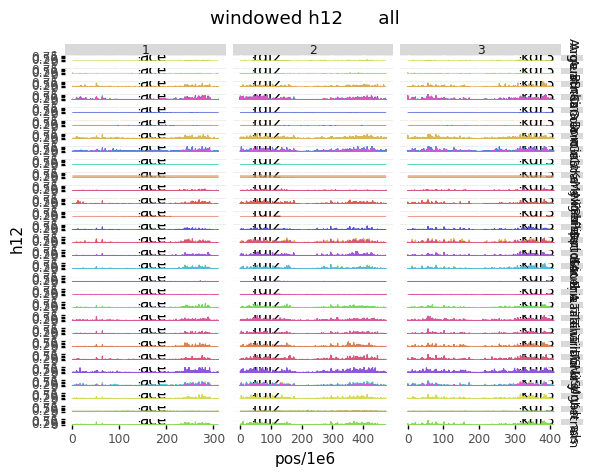

In [15]:
p = ggplot(h12tab,aes(x='pos/1e6',y="h12")) + \
  geom_vline(aes(xintercept='pos/1e6'),data=haps,linetype="dotted") +\
  geom_text(aes(x='pos/1e6',label='locusname'),data=haps,y=0.9,ha='left') +\
  geom_line(aes(x='pos/1e6',color="pop")) + \
  ggtitle("windowed h12      {p1}".format(p1="all")) +\
  theme(legend_position='none') + facet_grid(("cnt","chr"),scales="free_x",space="free_x")
ggsave(plot=p, width=500,height=200,units='mm',filename='h12_{}bp_allchroms_allpops_thinrand.png'.format(blen), dpi=400)
print(p)


/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 500.0 x 200.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_500bp_allchroms_Americas_thinrand.png


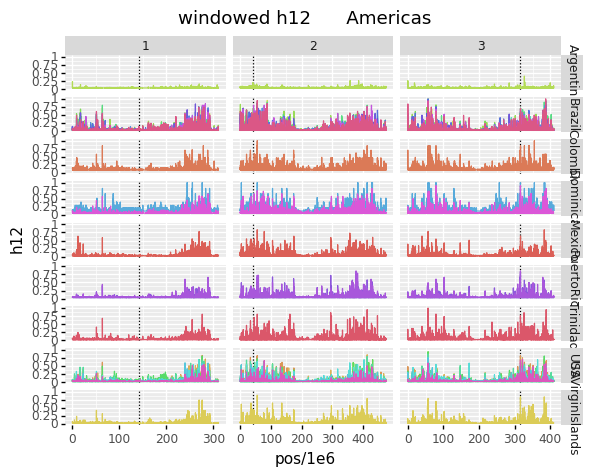

/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 500.0 x 200.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_500bp_allchroms_Asia_thinrand.png


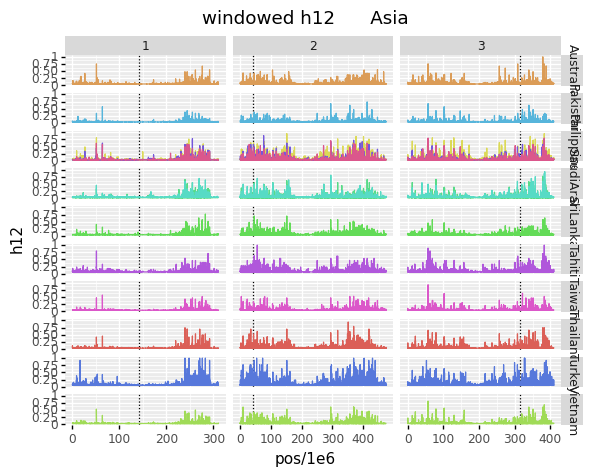

/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 500.0 x 200.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_500bp_allchroms_Eafrica_thinrand.png


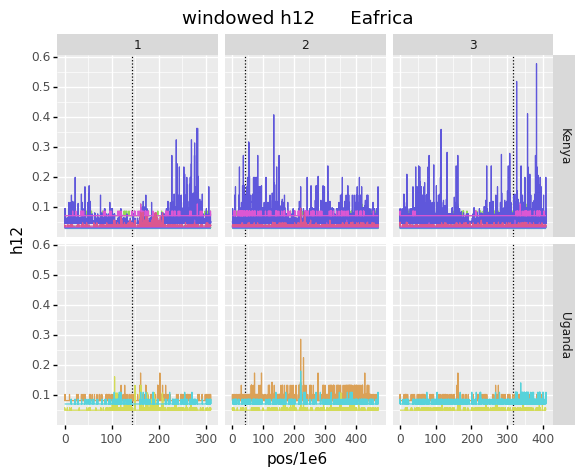

/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 500.0 x 200.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_500bp_allchroms_Safrica_thinrand.png


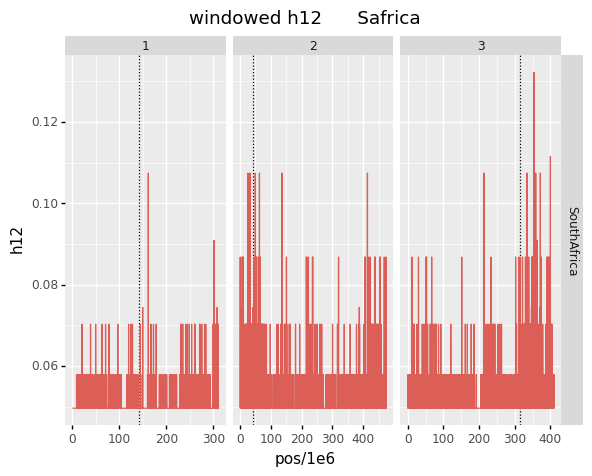

/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 500.0 x 200.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_500bp_allchroms_Wafrica_thinrand.png


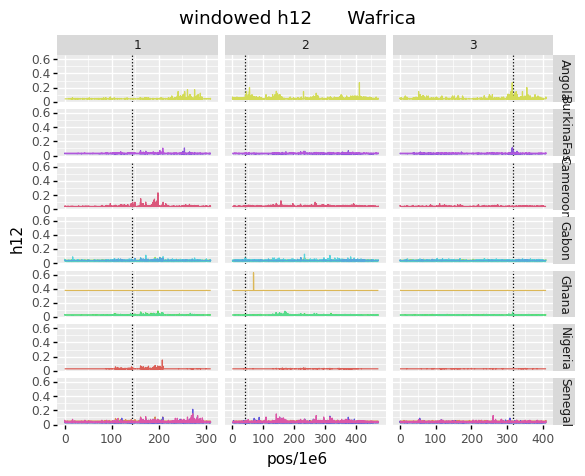

In [34]:
for region in np.unique(meta['contgroup']):
    h12region = h12tab[h12tab['pop'].isin(np.unique(meta['pop'][meta['contgroup']==region]))]

    p = ggplot(h12region,aes(x='pos/1e6',y="h12")) + \
      geom_vline(aes(xintercept='pos/1e6'),data=haps,linetype="dotted") +\
      geom_line(aes(x='pos/1e6',color="pop")) + \
      ggtitle("windowed h12      {p1}".format(p1=region)) +\
      theme(legend_position='none') + facet_grid(("cnt","chr"),scales="free_x",space="free_x")
    ggsave(plot=p, width=500,height=200,units='mm',filename='h12_{}bp_allchroms_{}_thinrand.png'.format(blen,region), dpi=400)
    print(p)

    
    

In [31]:
region = "Asia"

np.unique(meta['pop'][meta['contgroup']==region])


array(['Bangkok', 'Cairns', 'CebuCity', 'HoChiMin', 'Jaffna', 'Jeddah',
       'Mecca', 'Pakistan', 'Pazar', 'RuralSulawesi', 'Tahiti', 'Taiwan',
       'UrbanSulawesi'], dtype='<U14')